**Capítulo 6 - Árvores de Decisão**

*Este notebook mostra como árvores de decisão fazem previsões, estimam probabilidades, controlam complexidade e também podem ser usadas para regressão. No final, exploramos a estrutura interna da árvore treinada.*

*Este notebook contém a tradução e adaptação das células de exemplo do Capítulo 6. A seção final de soluções dos exercícios foi deixada fora do notebook principal e ficará organizada em `Respostas.md`.*

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/06_decision_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir no Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/06_decision_trees.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Configuração

*Começamos verificando versões, preparando os gráficos e criando uma função para salvar figuras. Árvores são fáceis de visualizar, então este capítulo usa bastante saída gráfica.*

*Este projeto requer Python 3.7 ou superior.*

In [12]:
import sys, graphviz
import subprocess

assert sys.version_info >= (3, 7)

*Ele também requer Scikit-Learn >= 1.0.1.*

In [13]:
from packaging import version
import sklearn
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

*Como nos capítulos anteriores, definimos tamanhos padrão de fonte para deixar as figuras mais legíveis.*

In [14]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

*Também criamos a pasta `images/decision_trees`, caso ainda não exista, e definimos `save_fig()`, usada ao longo do notebook para salvar figuras em alta resolução.*

In [15]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "decision_trees"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# Treinando e Visualizando uma Árvore de Decisão

*Árvores de decisão dividem o espaço de atributos em regiões usando perguntas simples. Começamos com o conjunto de dados Iris para visualizar uma árvore pequena e interpretável.*

In [16]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
y_iris = iris.target

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

**Este exemplo de código gera a Figura 6-1: árvore de decisão para o Iris.**

In [17]:
from sklearn.tree import export_graphviz

export_graphviz(
        tree_clf,
        out_file=str(IMAGES_PATH / "iris_tree.dot"),  # o caminho é diferente no livro
        feature_names=["petal length (cm)", "petal width (cm)"],
        class_names=iris.target_names,
        rounded=True,
        filled=True
    )

In [18]:
from graphviz import Source

Source.from_file(IMAGES_PATH / "iris_tree.dot")  # o caminho é diferente no livro

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

*O Graphviz também fornece o comando `dot`, que converte arquivos `.dot` para vários formatos. O comando abaixo converte o arquivo da árvore para uma imagem PNG.*

In [19]:
# código extra
!dot -Tpng {IMAGES_PATH / "iris_tree.dot"} -o {IMAGES_PATH / "iris_tree.png"}

fish: Unknown command: dot
fish: 
dot -Tpng images/decision_trees/iris_tree.dot -o images/decision_trees/iris_tree.png
^~^


# Fazendo Previsões

*Para prever, a árvore percorre os nós a partir da raiz até chegar a uma folha. Cada nó testa um atributo contra um limiar e decide seguir para a esquerda ou para a direita.*

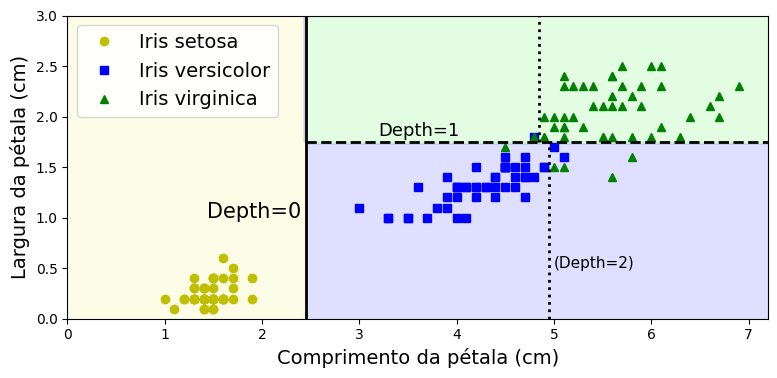

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# código extra – apenas detalhes de formatação
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])
plt.figure(figsize=(8, 4))

lengths, widths = np.meshgrid(np.linspace(0, 7.2, 100), np.linspace(0, 3, 100))
X_iris_all = np.c_[lengths.ravel(), widths.ravel()]
y_pred = tree_clf.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

# código extra – esta seção melhora o gráfico e salva a Figura 6–2
tree_clf_deeper = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf_deeper.fit(X_iris, y_iris)
th0, th1, th2a, th2b = tree_clf_deeper.tree_.threshold[[0, 2, 3, 6]]
plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Largura da pétala (cm)")
plt.plot([th0, th0], [0, 3], "k-", linewidth=2)
plt.plot([th0, 7.2], [th1, th1], "k--", linewidth=2)
plt.plot([th2a, th2a], [0, th1], "k:", linewidth=2)
plt.plot([th2b, th2b], [th1, 3], "k:", linewidth=2)
plt.text(th0 - 0.05, 1.0, "Depth=0", horizontalalignment="right", fontsize=15)
plt.text(3.2, th1 + 0.02, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.text(th2a + 0.05, 0.5, "(Depth=2)", fontsize=11)
plt.axis([0, 7.2, 0, 3])
plt.legend()
save_fig("decision_tree_decision_boundaries_plot")

plt.show()

*Podemos acessar a estrutura da árvore pelo atributo `tree_`.*

In [21]:
tree_clf.tree_

*Para mais informações, consulte a documentação dessa classe.*

In [22]:
# help(sklearn.tree._tree.Tree)

*Veja a seção de material extra abaixo para um exemplo mais detalhado.*

# Estimando Probabilidades de Classes

*Uma árvore estima probabilidades olhando a proporção de classes entre as instâncias de treino que chegaram à folha final.*

In [23]:
tree_clf.predict_proba([[5, 1.5]]).round(3)

array([[0.   , 0.907, 0.093]])

In [24]:
tree_clf.predict([[5, 1.5]])

array([1])

# Hiperparâmetros de Regularização

*Árvores podem crescer até decorar o treino. Hiperparâmetros como `max_depth`, `min_samples_leaf` e `min_samples_split` limitam a complexidade e ajudam a reduzir sobreajuste.*

In [25]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

DecisionTreeClassifier(min_samples_leaf=5, random_state=42)

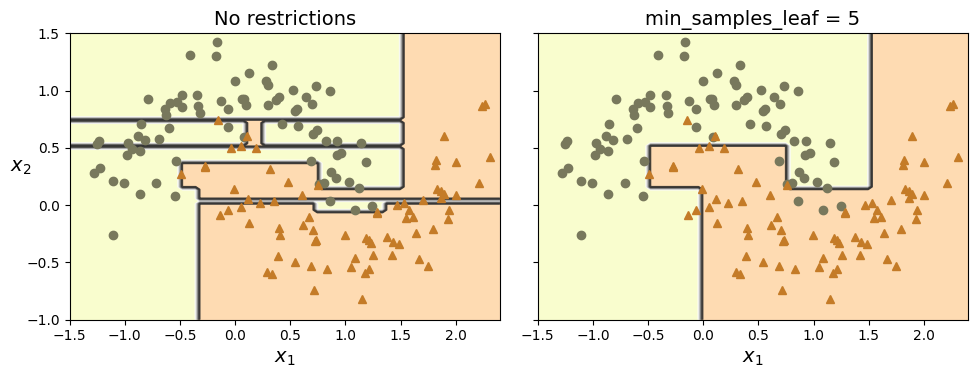

In [26]:
# código extra – esta célula gera e salva a Figura 6–3

def plot_decision_boundary(clf, X, y, axes, cmap):
    x1, x2 = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                         np.linspace(axes[2], axes[3], 100))
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=cmap)
    plt.contour(x1, x2, y_pred, cmap="Greys", alpha=0.8)
    colors = {"Wistia": ["#78785c", "#c47b27"], "Pastel1": ["red", "blue"]}
    markers = ("o", "^")
    for idx in (0, 1):
        plt.plot(X[:, 0][y == idx], X[:, 1][y == idx],
                 color=colors[cmap][idx], marker=markers[idx], linestyle="none")
    plt.axis(axes)
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$", rotation=0)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf1, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title("No restrictions")
plt.sca(axes[1])
plot_decision_boundary(tree_clf2, X_moons, y_moons,
                       axes=[-1.5, 2.4, -1, 1.5], cmap="Wistia")
plt.title(f"min_samples_leaf = {tree_clf2.min_samples_leaf}")
plt.ylabel("")
save_fig("min_samples_leaf_plot")
plt.show()

In [27]:
X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2,
                                        random_state=43)
tree_clf1.score(X_moons_test, y_moons_test)

0.898

In [28]:
tree_clf2.score(X_moons_test, y_moons_test)

0.92

# Regressão

*Árvores de decisão também podem resolver problemas de regressão. Nesse caso, cada folha prevê um valor numérico, geralmente a média dos alvos das instâncias naquela região.*

*Vamos preparar um conjunto de treino quadrático simples.*

**Exemplo de código:**

In [29]:
from sklearn.tree import DecisionTreeRegressor

np.random.seed(42)
X_quad = np.random.rand(200, 1) - 0.5  # uma única característica de entrada aleatória
y_quad = X_quad ** 2 + 0.025 * np.random.randn(200, 1)

tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=2, random_state=42)

In [30]:
# código extra – já vimos como usar export_graphviz()
export_graphviz(
    tree_reg,
    out_file=str(IMAGES_PATH / "regression_tree.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True
)
Source.from_file(IMAGES_PATH / "regression_tree.dot")

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [31]:
tree_reg2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_reg2.fit(X_quad, y_quad)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [32]:
tree_reg.tree_.threshold

array([-0.30265072, -0.40830374, -2.        , -2.        ,  0.27175756,
       -2.        , -2.        ])

In [33]:
tree_reg2.tree_.threshold

array([-0.30265072, -0.40830374, -0.45416115, -2.        , -2.        ,
       -0.37022041, -2.        , -2.        ,  0.27175756, -0.21270403,
       -2.        , -2.        ,  0.40399227, -2.        , -2.        ])

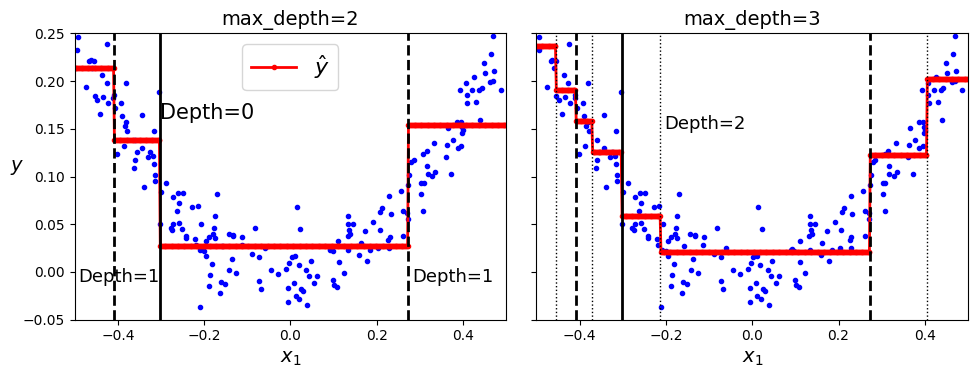

In [34]:
# código extra – esta célula gera e salva a Figura 6–5

def plot_regression_predictions(tree_reg, X, y, axes=[-0.5, 0.5, -0.05, 0.25]):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.axis(axes)
    plt.xlabel("$x_1$")
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_regression_predictions(tree_reg, X_quad, y_quad)

th0, th1a, th1b = tree_reg.tree_.threshold[[0, 1, 4]]
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
plt.text(th0, 0.16, "Depth=0", fontsize=15)
plt.text(th1a + 0.01, -0.01, "Depth=1", horizontalalignment="center", fontsize=13)
plt.text(th1b + 0.01, -0.01, "Depth=1", fontsize=13)
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center", fontsize=16)
plt.title("max_depth=2")

plt.sca(axes[1])
th2s = tree_reg2.tree_.threshold[[2, 5, 9, 12]]
plot_regression_predictions(tree_reg2, X_quad, y_quad)
for split, style in ((th0, "k-"), (th1a, "k--"), (th1b, "k--")):
    plt.plot([split, split], [-0.05, 0.25], style, linewidth=2)
for split in th2s:
    plt.plot([split, split], [-0.05, 0.25], "k:", linewidth=1)
plt.text(th2s[2] + 0.01, 0.15, "Depth=2", fontsize=13)
plt.title("max_depth=3")

save_fig("tree_regression_plot")
plt.show()

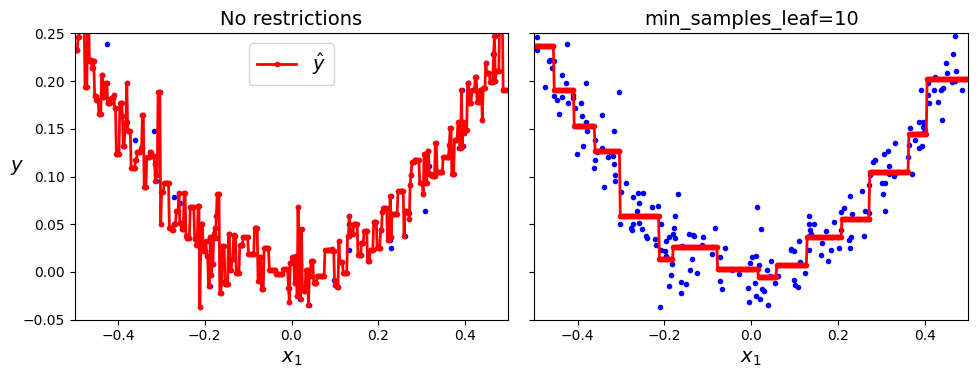

In [35]:
# código extra – esta célula gera e salva a Figura 6–6

tree_reg1 = DecisionTreeRegressor(random_state=42)
tree_reg2 = DecisionTreeRegressor(random_state=42, min_samples_leaf=10)
tree_reg1.fit(X_quad, y_quad)
tree_reg2.fit(X_quad, y_quad)

x1 = np.linspace(-0.5, 0.5, 500).reshape(-1, 1)
y_pred1 = tree_reg1.predict(x1)
y_pred2 = tree_reg2.predict(x1)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)

plt.sca(axes[0])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred1, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper center")
plt.title("No restrictions")

plt.sca(axes[1])
plt.plot(X_quad, y_quad, "b.")
plt.plot(x1, y_pred2, "r.-", linewidth=2, label=r"$\hat{y}$")
plt.axis([-0.5, 0.5, -0.05, 0.25])
plt.xlabel("$x_1$")
plt.title(f"min_samples_leaf={tree_reg2.min_samples_leaf}")

save_fig("tree_regression_regularization_plot")
plt.show()

# Sensibilidade à Orientação dos Eixos

*Árvores fazem divisões perpendiculares aos eixos dos atributos. Por isso, uma simples rotação dos dados pode mudar bastante a fronteira de decisão.*

*Rotacionar o conjunto de dados também leva a fronteiras de decisão completamente diferentes.*

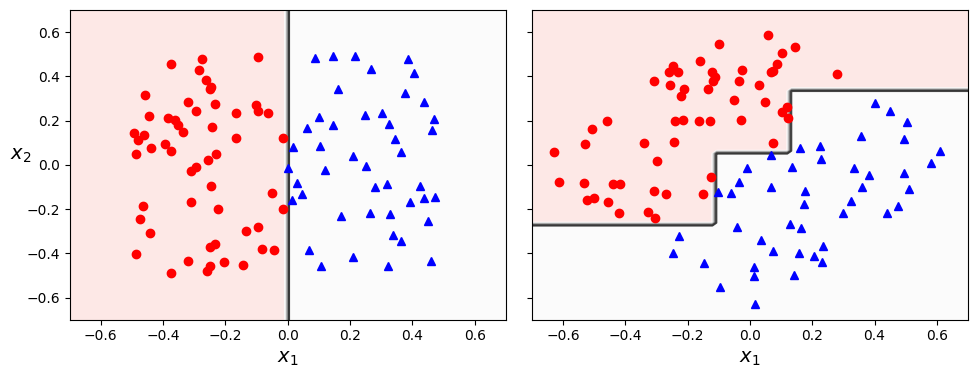

In [36]:
# código extra – esta célula gera e salva a Figura 6–7

np.random.seed(6)
X_square = np.random.rand(100, 2) - 0.5
y_square = (X_square[:, 0] > 0).astype(np.int64)

angle = np.pi / 4  # 45 graus
rotation_matrix = np.array([[np.cos(angle), -np.sin(angle)],
                            [np.sin(angle), np.cos(angle)]])
X_rotated_square = X_square.dot(rotation_matrix)

tree_clf_square = DecisionTreeClassifier(random_state=42)
tree_clf_square.fit(X_square, y_square)
tree_clf_rotated_square = DecisionTreeClassifier(random_state=42)
tree_clf_rotated_square.fit(X_rotated_square, y_square)

fig, axes = plt.subplots(ncols=2, figsize=(10, 4), sharey=True)
plt.sca(axes[0])
plot_decision_boundary(tree_clf_square, X_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")
plt.sca(axes[1])
plot_decision_boundary(tree_clf_rotated_square, X_rotated_square, y_square,
                       axes=[-0.7, 0.7, -0.7, 0.7], cmap="Pastel1")
plt.ylabel("")

save_fig("sensitivity_to_rotation_plot")
plt.show()

In [37]:
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pca_pipeline = make_pipeline(StandardScaler(), PCA())
X_iris_rotated = pca_pipeline.fit_transform(X_iris)
tree_clf_pca = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf_pca.fit(X_iris_rotated, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

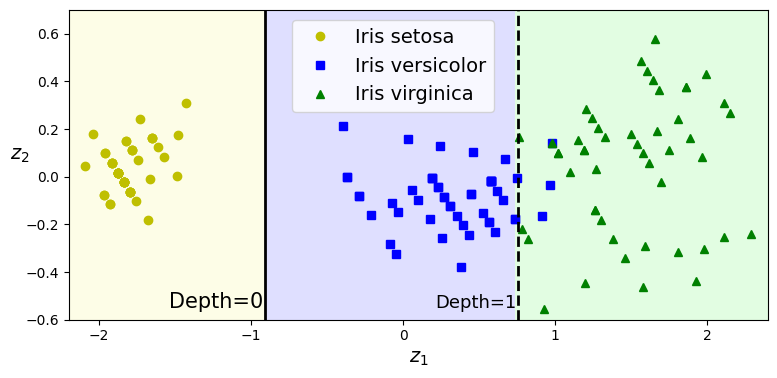

In [38]:
# código extra – esta célula gera e salva a Figura 6–8

plt.figure(figsize=(8, 4))

axes = [-2.2, 2.4, -0.6, 0.7]
z0s, z1s = np.meshgrid(np.linspace(axes[0], axes[1], 100),
                       np.linspace(axes[2], axes[3], 100))
X_iris_pca_all = np.c_[z0s.ravel(), z1s.ravel()]
y_pred = tree_clf_pca.predict(X_iris_pca_all).reshape(z0s.shape)

plt.contourf(z0s, z1s, y_pred, alpha=0.3, cmap=custom_cmap)
for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris_rotated[:, 0][y_iris == idx],
             X_iris_rotated[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
th1, th2 = tree_clf_pca.tree_.threshold[[0, 2]]
plt.plot([th1, th1], axes[2:], "k-", linewidth=2)
plt.plot([th2, th2], axes[2:], "k--", linewidth=2)
plt.text(th1 - 0.01, axes[2] + 0.05, "Depth=0",
         horizontalalignment="right", fontsize=15)
plt.text(th2 - 0.01, axes[2] + 0.05, "Depth=1",
         horizontalalignment="right", fontsize=13)
plt.axis(axes)
plt.legend(loc=(0.32, 0.67))
save_fig("pca_preprocessing_plot")

plt.show()

# Árvores de Decisão Têm Alta Variância

*Pequenas mudanças nos dados ou na aleatoriedade do treinamento podem gerar árvores bem diferentes. Essa instabilidade é uma das motivações para Florestas Aleatórias no próximo capítulo.*

*Vimos que pequenas mudanças no conjunto de dados, como uma rotação, podem produzir uma árvore muito diferente. Agora vamos mostrar que treinar o mesmo modelo nos mesmos dados também pode produzir modelos distintos, pois o algoritmo CART usado pelo Scikit-Learn é estocástico. Para isso, mudamos `random_state`.*

In [39]:
tree_clf_tweaked = DecisionTreeClassifier(max_depth=2, random_state=40)
tree_clf_tweaked.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=40)

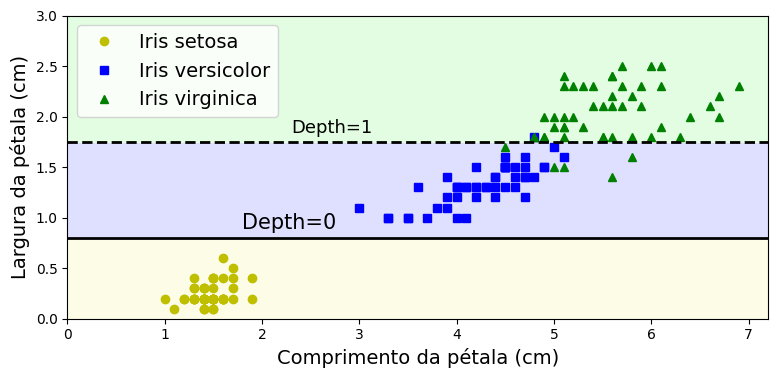

In [40]:
# código extra – esta célula gera e salva a Figura 6–9

plt.figure(figsize=(8, 4))
y_pred = tree_clf_tweaked.predict(X_iris_all).reshape(lengths.shape)
plt.contourf(lengths, widths, y_pred, alpha=0.3, cmap=custom_cmap)

for idx, (name, style) in enumerate(zip(iris.target_names, ("yo", "bs", "g^"))):
    plt.plot(X_iris[:, 0][y_iris == idx], X_iris[:, 1][y_iris == idx],
             style, label=f"Iris {name}")

th0, th1 = tree_clf_tweaked.tree_.threshold[[0, 2]]
plt.plot([0, 7.2], [th0, th0], "k-", linewidth=2)
plt.plot([0, 7.2], [th1, th1], "k--", linewidth=2)
plt.text(1.8, th0 + 0.05, "Depth=0", verticalalignment="bottom", fontsize=15)
plt.text(2.3, th1 + 0.05, "Depth=1", verticalalignment="bottom", fontsize=13)
plt.xlabel("Comprimento da pétala (cm)")
plt.ylabel("Largura da pétala (cm)")
plt.axis([0, 7.2, 0, 3])
plt.legend()
save_fig("decision_tree_high_variance_plot")

plt.show()

# Material Adicional - Acessando a Estrutura da Árvore

*Esta seção mostra como inspecionar a árvore treinada por dentro. Isso ajuda a entender como o Scikit-Learn armazena nós, limiares, filhos e contagens de classes.*

*Um `DecisionTreeClassifier` treinado possui um atributo `tree_` que guarda a estrutura da árvore.*

In [41]:
tree = tree_clf.tree_
tree

*Podemos obter o número total de nós da árvore.*

In [42]:
tree.node_count

5

*Outros atributos autoexplicativos também estão disponíveis.*

In [43]:
tree.max_depth

2

In [44]:
tree.max_n_classes

3

In [45]:
tree.n_features

2

In [46]:
tree.n_outputs

1

In [47]:
tree.n_leaves

np.int64(3)

*Todas as informações sobre os nós ficam armazenadas em arrays NumPy. Por exemplo, a impureza de cada nó.*

In [48]:
tree.impurity

array([0.66666667, 0.        , 0.5       , 0.16803841, 0.04253308])

*O nó raiz está no índice 0. Os filhos esquerdo e direito do nó _i_ são `tree.children_left[i]` e `tree.children_right[i]`. Por exemplo, os filhos da raiz são:*

In [49]:
tree.children_left[0], tree.children_right[0]

(np.int64(1), np.int64(2))

*Quando os nós esquerdo e direito são iguais, isso significa que o nó é uma folha; os identificadores dos filhos são arbitrários.*

In [50]:
tree.children_left[3], tree.children_right[3]

(np.int64(-1), np.int64(-1))

*Assim, podemos obter os identificadores dos nós folha desta forma.*

In [51]:
is_leaf = (tree.children_left == tree.children_right)
np.arange(tree.node_count)[is_leaf]

array([1, 3, 4])

*Nós que não são folhas são chamados de nós de divisão. O atributo usado na divisão fica no array `feature`. Os valores para folhas devem ser ignorados.*

In [52]:
tree.feature

array([ 0, -2,  1, -2, -2], dtype=int64)

*Os limiares correspondentes são estes.*

In [53]:
tree.threshold

array([ 2.44999999, -2.        ,  1.75      , -2.        , -2.        ])

*A quantidade de instâncias por classe que chegou a cada nó também fica disponível.*

In [54]:
tree.value

array([[[0.33333333, 0.33333333, 0.33333333]],

       [[1.        , 0.        , 0.        ]],

       [[0.        , 0.5       , 0.5       ]],

       [[0.        , 0.90740741, 0.09259259]],

       [[0.        , 0.02173913, 0.97826087]]])

In [55]:
tree.n_node_samples

array([150,  50, 100,  54,  46], dtype=int64)

In [56]:
np.all(tree.value.sum(axis=(1, 2)) == tree.n_node_samples)

np.False_

*Veja como calcular a profundidade de cada nó.*

In [57]:
def compute_depth(tree_clf):
    tree = tree_clf.tree_
    depth = np.zeros(tree.node_count)
    stack = [(0, 0)]
    while stack:
        node, node_depth = stack.pop()
        depth[node] = node_depth
        if tree.children_left[node] != tree.children_right[node]:
            stack.append((tree.children_left[node], node_depth + 1))
            stack.append((tree.children_right[node], node_depth + 1))
    return depth

depth = compute_depth(tree_clf)
depth

array([0., 1., 1., 2., 2.])

*Veja como obter os limiares de todos os nós de divisão na profundidade 1.*

In [58]:
tree_clf.tree_.feature[(depth == 1) & (~is_leaf)]

array([1], dtype=int64)

In [59]:
tree_clf.tree_.threshold[(depth == 1) & (~is_leaf)]

array([1.75])